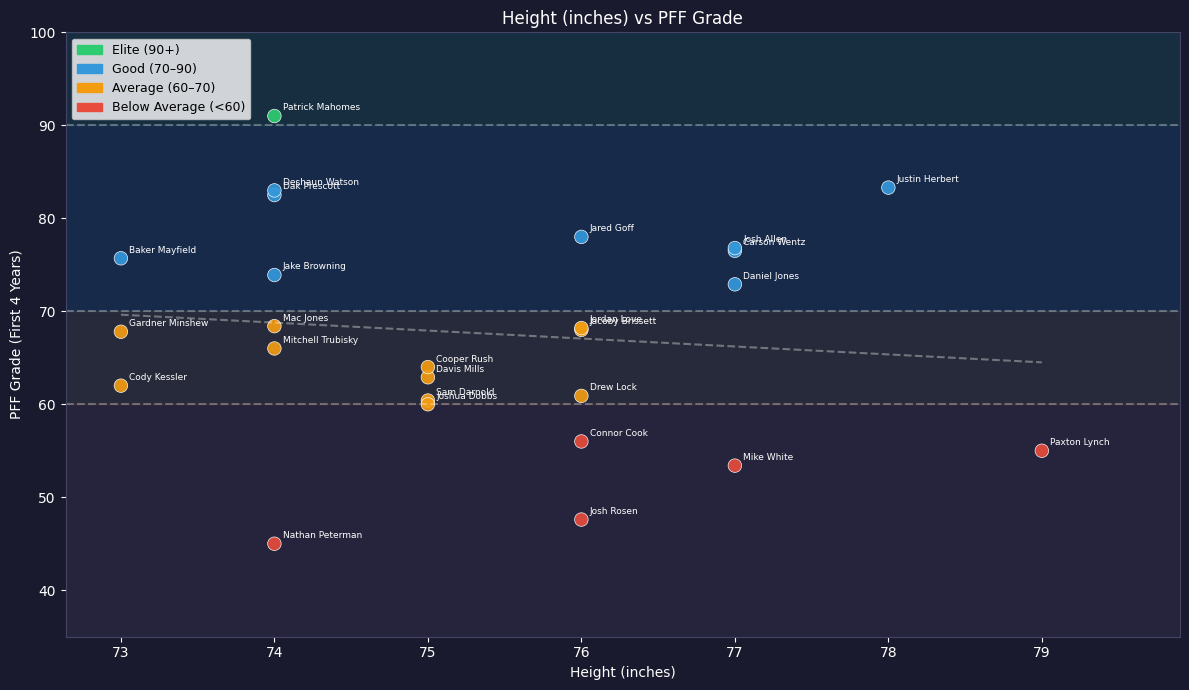

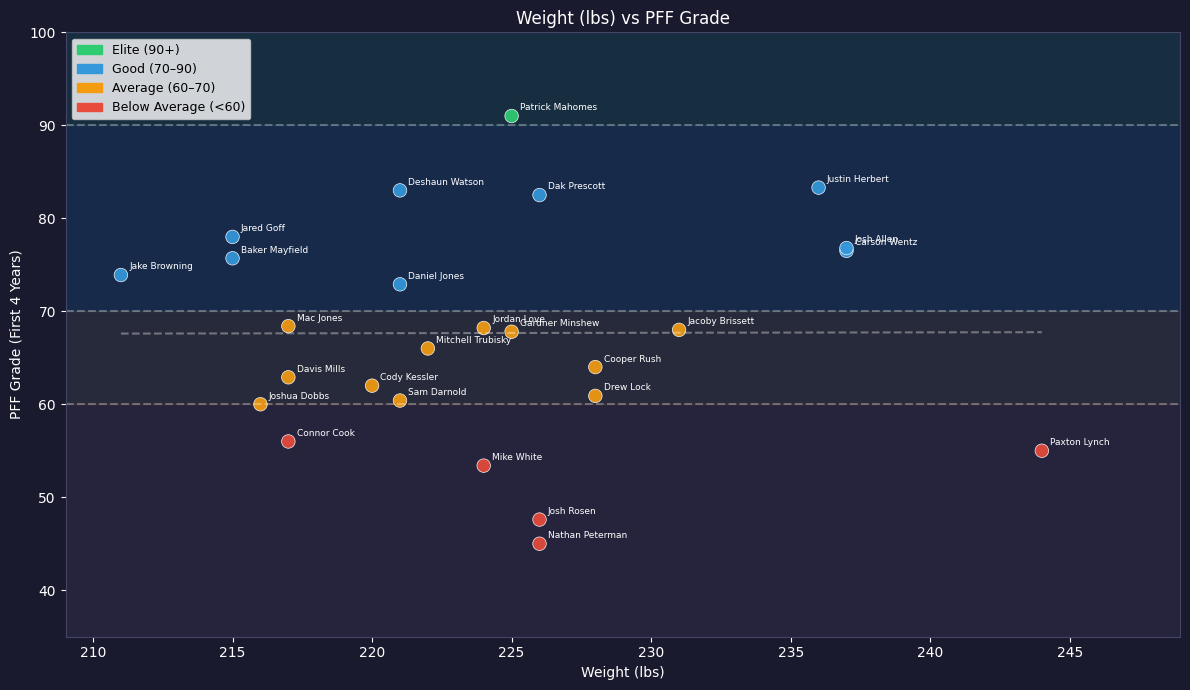

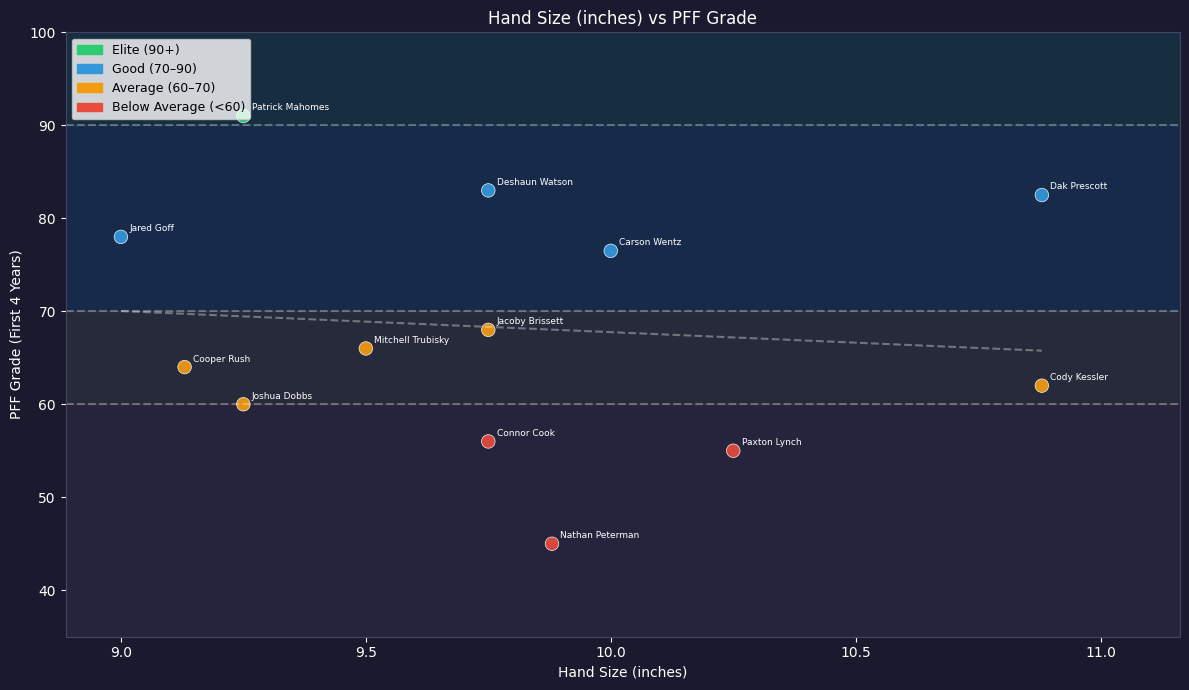

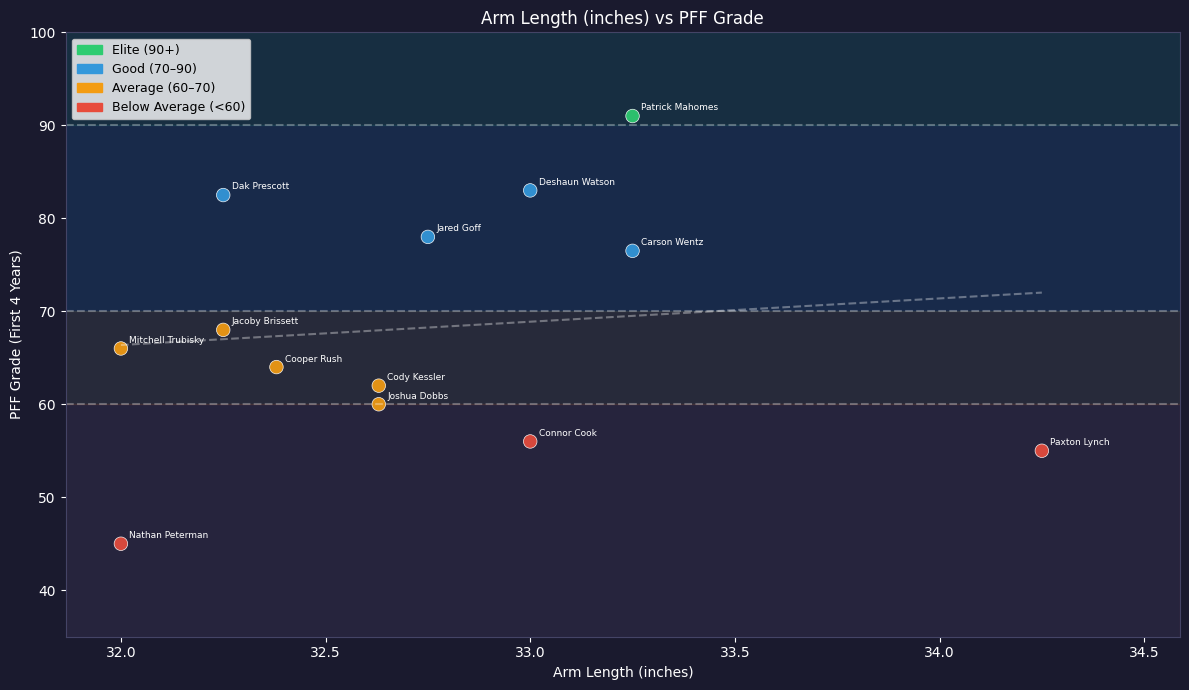

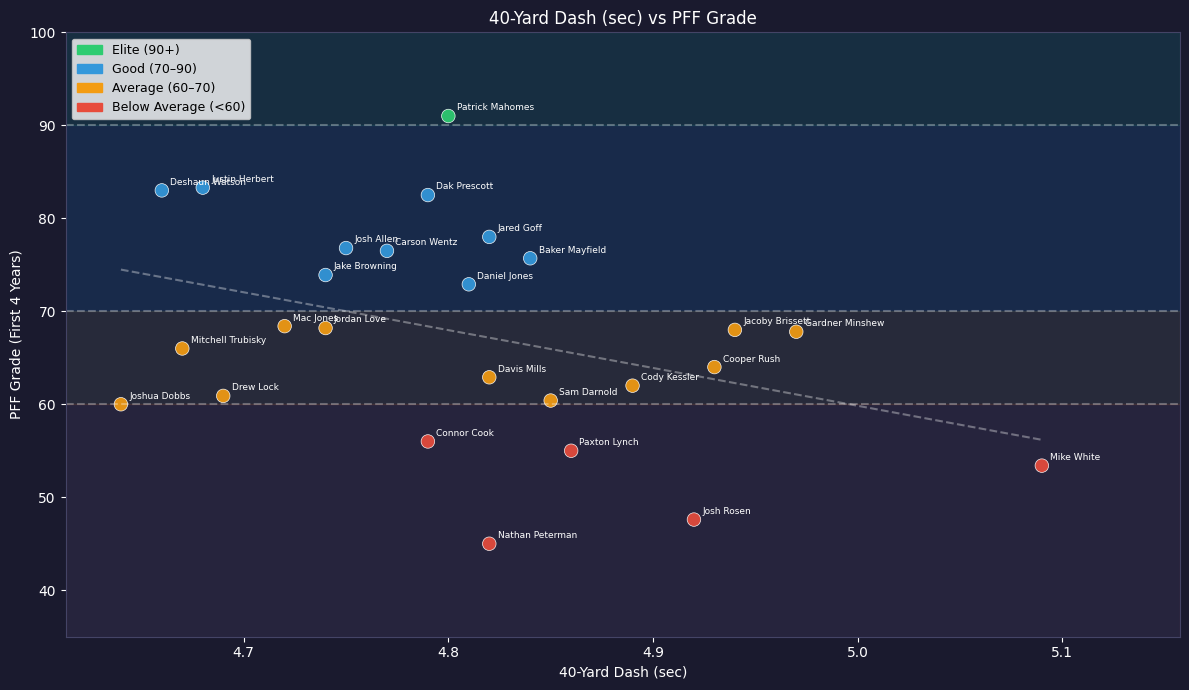

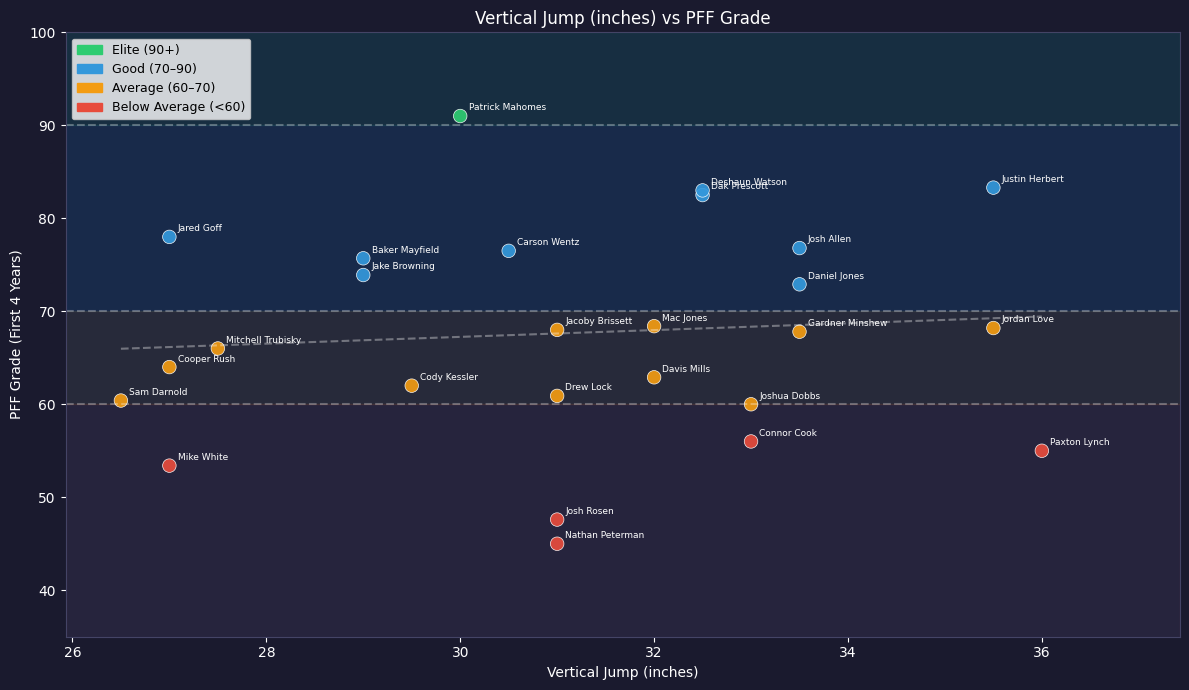

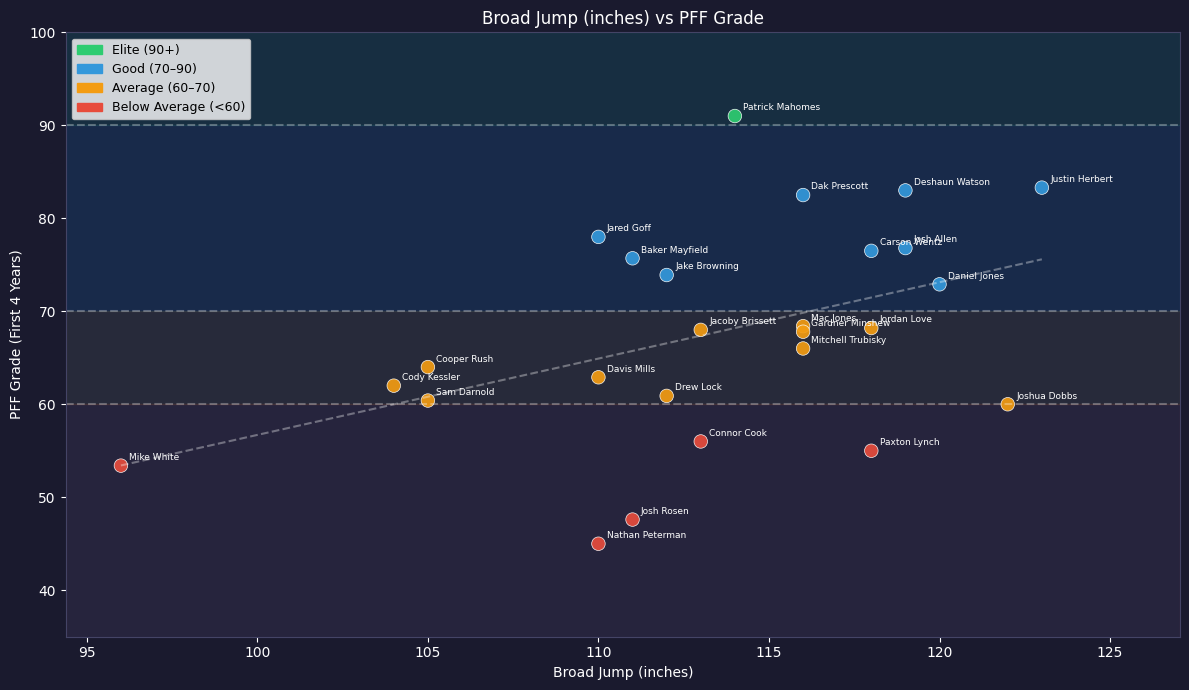

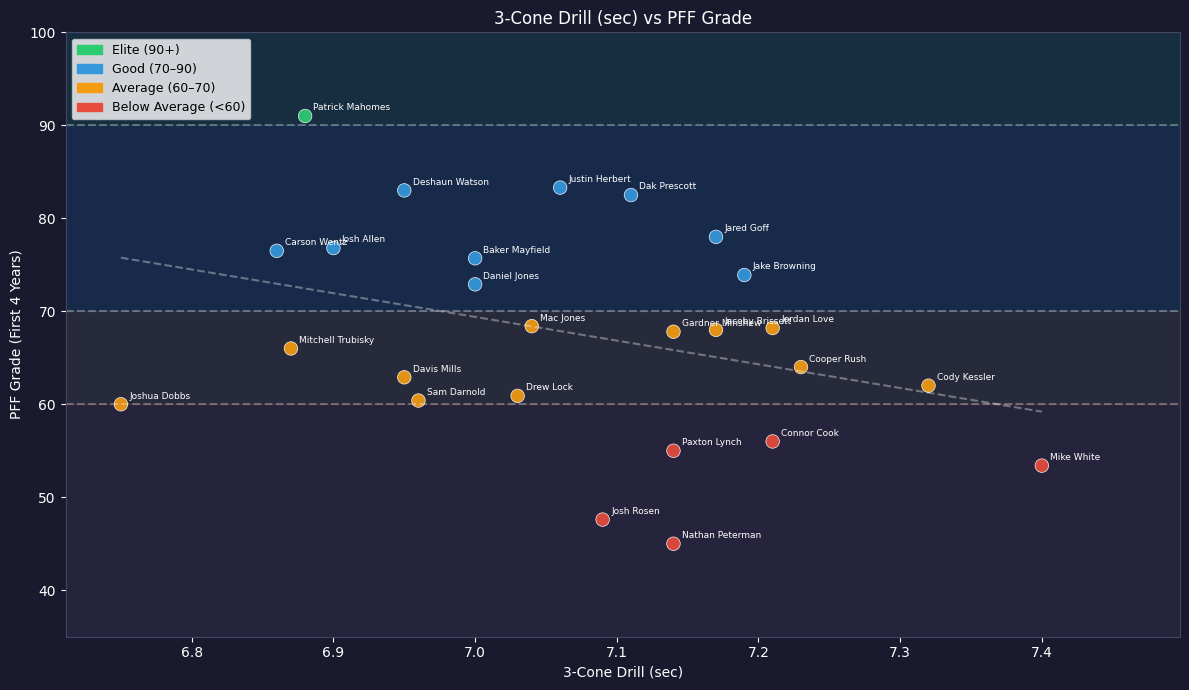

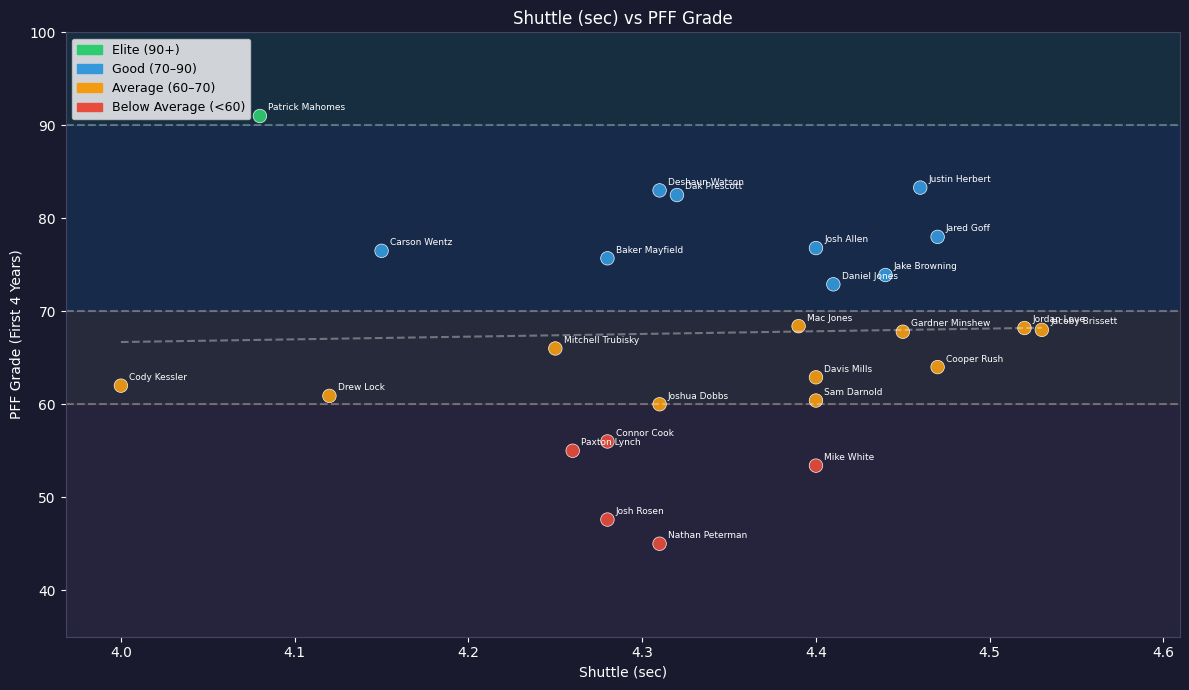

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("QB_Combine_Data.csv")
df.columns = df.columns.str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# ── PFF Column ────────────────────────────────────────────────────────────────
pff_col = [c for c in df.columns if "PFF" in c.upper()][0]
df["PFF"] = pd.to_numeric(df[pff_col], errors="coerce")

# ── Conversions ───────────────────────────────────────────────────────────────
def height_to_inches(h):
    try:
        h = str(h).replace('"', '')
        feet, inches = h.split("'")
        return int(feet) * 12 + int(inches or 0)
    except:
        return np.nan

def jump_to_inches(val):
    try:
        val = str(val).replace('"', '')
        if "'" in val:
            feet, inches = val.split("'")
            return int(feet) * 12 + int(inches)
        return float(val)
    except:
        return np.nan

df["Height_in"] = df["Height"].apply(height_to_inches)

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics = [
    ("Height_in", "Height (inches)", None),
    ("Weight", "Weight (lbs)", None),
    ("Hands", "Hand Size (inches)", None),
    ("Arms", "Arm Length (inches)", None),
    ("Wingspan", "Wingspan (inches)", None),
    ("40 Yd", "40-Yard Dash (sec)", None),
    ("10 Split", "10-Yard Split (sec)", None),
    ("Vertical", "Vertical Jump (inches)", None),
    ("Broad", "Broad Jump (inches)", jump_to_inches),
    ("Bench", "Bench Press (reps)", None),
    ("3-Cone", "3-Cone Drill (sec)", None),
    ("Shuttle", "Shuttle (sec)", None),
]

# ── Bands ─────────────────────────────────────────────────────────────────────
bands = [
    (90, 100, "#2ecc71", "Elite (90+)"),
    (70, 90, "#3498db", "Good (70–90)"),
    (60, 70, "#f39c12", "Average (60–70)"),
    (0, 60, "#e74c3c", "Below Average (<60)"),
]

def get_color(pff):
    if pd.isna(pff): return "#aaaaaa"
    if pff >= 90: return "#2ecc71"
    elif pff >= 70: return "#3498db"
    elif pff >= 60: return "#f39c12"
    else: return "#e74c3c"

# ── Plot ──────────────────────────────────────────────────────────────────────
for col, xlabel, converter in metrics:

    if col not in df.columns:
        continue

    x_vals = df[col].apply(converter) if converter else pd.to_numeric(df[col], errors="coerce")
    y_vals = df["PFF"]

    mask = x_vals.notna() & y_vals.notna()
    x = x_vals[mask]
    y = y_vals[mask]
    names = df["Name"][mask]

    if x.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#16213e")

    # Bands
    for lo, hi, color, _ in bands:
        ax.axhspan(lo, hi, color=color, alpha=0.08)
    for t in [90, 70, 60]:
        ax.axhline(y=t, color="white", linestyle="--", alpha=0.3)

    # Scatter
    ax.scatter(x, y, c=[get_color(p) for p in y],
               s=95, edgecolors="white", linewidths=0.5, alpha=0.92)

    # Labels
    for xi, yi, name in zip(x, y, names):
        ax.annotate(name, (xi, yi), xytext=(6, 4),
                    textcoords="offset points", fontsize=6.5, color="white")

    # Trend line
    if len(x) >= 3:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 300)
        ax.plot(x_line, p(x_line), color="white", linestyle="--", alpha=0.35)

    # Limits
    x_pad = (x.max() - x.min()) * 0.06 if x.max() != x.min() else 0.5
    ax.set_xlim(x.min() - x_pad, x.max() + x_pad * 2.5)
    ax.set_ylim(35, 100)

    # Labels
    ax.set_xlabel(xlabel, color="white")
    ax.set_ylabel("PFF Grade (First 4 Years)", color="white")
    ax.set_title(f"{xlabel} vs PFF Grade", color="white")

    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

    # Legend
    legend_patches = [mpatches.Patch(color=c, label=lbl) for _, _, c, lbl in bands]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=9)

    plt.tight_layout()

    fname = f"qb_{xlabel.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())

    plt.show()